# Simulation of expected reconstructed event distribution from effective area and reconstruction 

## Calculation of effective area ...and more as it seems

### Calculation of Aeff

In [4]:
import numpy as np
import h5py
from astropy.table import Table
import numpy as np
import pandas as pd
import numba as nb
from numba import jit, njit, prange, float64, int64
from km3pipe.math import azimuth, zenith
import astropy.coordinates as ac
from astropy.time import Time
import astropy.units as u


def aeff_2D_eventlist(e_bins, t_bins, eventlist, gamma, n_runs, method=1):
    """
    Calculate the effective area in energy and zenith angle bins.

    Parameters
    ----------
    e_bins : Array
        of energy bins in GeV
    t_bins : Array
        of zenith angle bins in rad
    dataset : pandas.DataFrame
        with the events
    gamma : float, default 1.4
        spectral index of simulated events
    nevents : float, default 2e7
        number of generated events

    Returns
    -------
    2D-Array
        with the effective area in m^2 binned in energy and zenith angle bins

    """

    #if mcversion >= 9.0: T = 1.0
    #else: T = 365.25 * 24 *3600
        
    cos_theta = np.cos(eventlist["theta_mc"])
    theta_bins = np.searchsorted(t_bins, cos_theta) - 1

    #theta_bins = np.searchsorted(t_bins, eventlist['theta_mc']) - 1
    energy_bins = np.searchsorted(e_bins, eventlist['energy_mc']) - 1

    w2 = np.array(eventlist['normalized_weight'].value)
    E = np.array(eventlist['energy_mc'].value)
    
    if method == 1: aeff = fill_aeff_2D(e_bins, t_bins, energy_bins, theta_bins, w2, E, gamma)/n_runs
    elif method == 2: aeff = fill_aeff_2D_method2(e_bins, t_bins, energy_bins, theta_bins, w2, E)/n_runs
    else:
        raise ValueError("Unknown method. Choose method=1 or method=2.")
    return aeff


@njit(fastmath=False, parallel=True)
def fill_aeff_2D(e_bins, t_bins, energy_bins, theta_bins, w2, E, gamma):
    """
    numba accelerated helper function to calculate effective area.

    """
    #T = 365.25 * 24 * 3600
    #T = 1.0
    aeff = np.empty((len(e_bins) - 1, len(t_bins) - 1))
    for k in prange(len(e_bins) - 1):
        for i in range(len(t_bins) - 1):
            mask = (energy_bins == k) & (theta_bins == i)
            #d_omega = -(np.cos(t_bins[i + 1]) - np.cos(t_bins[i]))
            d_omega = (t_bins[i + 1] - t_bins[i])
            d_E = (e_bins[k + 1]) ** (1 - gamma) - (e_bins[k]) ** (1 - gamma)
            aeff[k, i] = (
                (1 - gamma)
                * np.sum(E[mask] ** (-gamma) * w2[mask])
                / (d_omega * d_E * 2 * np.pi)
            )

    return aeff


@njit(fastmath=False, parallel=True)
def fill_aeff_2D_method2(e_bins, t_bins, energy_bins, theta_bins, w2, E):
    """
    numba accelerated helper function to calculate effective area.

    """
    
    aeff = np.empty((len(e_bins) - 1, len(t_bins) - 1))
    for k in prange(len(e_bins) - 1):
        for i in range(len(t_bins) - 1):
            mask = (energy_bins == k) & (theta_bins == i)
            
            d_E = np.log10(e_bins[k + 1]/e_bins[k])
            d_Omega = 4 * np.pi/len(t_bins)
            #d_Omega = 2 * np.pi * (t_bins[i + 1] - t_bins[i])
            aeff[k, i] = (
                np.sum(E[mask] ** (-1) * w2[mask])
                / (np.log(10) * d_E * d_Omega)
            )

    return aeff


print("Functions built.")

def create_aeff_file_from_eventlist(config, output_path, gamma=1.4, method=1):
    """
    Computes and saves the 2D and 1D effective area for one or more neutrino flavors.

    Parameters
    ----------
    config : dict
        Dictionary with flavor-specific settings. Example:
        {
            "input_file": "/path/to/input.hdf5",
            "flavors": {
                "numu": {
                    "pdg_id": 14,
                    "nruns": 518,
                },
                "anue": {
                    "pdg_id": -12,
                    "nruns": 518,
                }
            }
        }
    output_path : str
        Path to save the resulting HDF5 file.
    gamma : float
        Spectral index of the simulated spectrum.
    method : int
        Method for computing the effective area (1 or 2).
    """

    #from your_module import aeff_2D_eventlist  # Replace with correct import

    print(f"Loading events from: {config['input_file']}")
    with h5py.File(config["input_file"], 'r') as h5_file:
        event_table = Table.read(h5_file)

    # Define binning
    E_min, E_max = 1e2, 1e8
    n_energy_bins, n_theta_bins = 100, 100
    energy_bins = np.logspace(np.log10(E_min), np.log10(E_max), n_energy_bins + 1)
    cos_theta_bins = np.linspace(-1.0, 1.0, n_theta_bins + 1)
    dcos = np.diff(cos_theta_bins)

    # Output structure
    with h5py.File(output_path, "w") as f:
        f.create_dataset("energy_bins", data=energy_bins)
        f.create_dataset("cos_theta_bins", data=cos_theta_bins)
        f.attrs["gamma"] = gamma
        f.attrs["method"] = method

        for flavor, info in config["flavors"].items():
            print(f"Processing flavor: {flavor}")

            # Select events
            pdg_id = info["pdg_id"]
            nruns = info["nruns"]
            flavor_events = event_table[event_table["pdg_id"] == pdg_id]

            # Compute effective areas
            aeff_2d = aeff_2D_eventlist(
                energy_bins,
                cos_theta_bins,
                flavor_events,
                gamma=gamma,
                n_runs=nruns,
                method=method
            )

            aeff_1d = np.sum(aeff_2d * dcos[np.newaxis, :] * 0.5, axis=1)

            # Store in HDF5
            grp = f.create_group(flavor)
            grp.create_dataset("aeff_2d", data=aeff_2d)
            grp.create_dataset("aeff_1d", data=aeff_1d)
            grp.attrs["pdg_id"] = pdg_id
            grp.attrs["nruns"] = nruns

    print(f"Saved A_eff data to {output_path}")



Functions built.


In [5]:
config = {
    "input_file": "/home/wecapstor3/capn/capn107h/combined_eventlists/arca_KM3NeT_00000133_0001_combined_4983084events_mc.hdf5",
    "flavors": {
        "numu": {
            "pdg_id": 14,
            "nruns": 518
        },
        "anumu": {
            "pdg_id": -14,
            "nruns": 518
        },
        "anue": {
            "pdg_id": -12,
            "nruns": 518
        },
        "nue": {
            "pdg_id": 12,
            "nruns": 518
        }
    }
}

output_path = "aeff_summary_v9_flavors.hdf5"
create_aeff_file_from_eventlist(config, output_path, gamma=1.4)

Loading events from: /home/wecapstor3/capn/capn107h/combined_eventlists/arca_KM3NeT_00000133_0001_combined_4983084events_mc.hdf5
Processing flavor: numu
Processing flavor: anumu
Processing flavor: anue
Processing flavor: nue
Saved A_eff data to aeff_summary_v9_flavors.hdf5


In [6]:
def load_aeff(file_path, flavor):
    with h5py.File(file_path, 'r') as f:

        aeff_1d = f[flavor]['aeff_1d'][()]
        aeff_2d = f[flavor]['aeff_2d'][()]
        bins = f['energy_bins'][()]
    return aeff_1d, aeff_2d, bins


aeff_1d, aeff_2d, energy_bins = load_aeff("aeff_summary_v9_flavors.hdf5", "numu")

In [7]:
def load_aeff_multi(file_path, flavors):
    """Load effective area data for multiple neutrino flavors.

    Parameters
    ----------
    file_path : str
        Path to the HDF5 file with A_eff data.
    flavors : list of str
        List of flavor keys to load.

    Returns
    -------
    dict
        Dictionary with each flavor as a key, and values being a dict with
        'aeff_1d', 'aeff_2d', 'energy_bins', 'cos_theta_bins' and optional metadata.
    """
    data = {}
    with h5py.File(file_path, 'r') as f:
        energy_bins = f['energy_bins'][()]
        cos_theta_bins = f['cos_theta_bins'][()]
        gamma = f.attrs.get('gamma', None)
        method = f.attrs.get('method', None)

        for flavor in flavors:
            if flavor in f:
                grp = f[flavor]
                data[flavor] = {
                    "aeff_1d": grp['aeff_1d'][()],
                    "aeff_2d": grp['aeff_2d'][()],
                    "energy_bins": energy_bins,
                    "cos_theta_bins": cos_theta_bins,
                    "pdg_id": grp.attrs.get("pdg_id", None),
                    "nruns": grp.attrs.get("nruns", None),
                    "gamma": gamma,
                    "method": method,
                }
            else:
                print(f"Warning: Flavor '{flavor}' not found in file.")
    return data


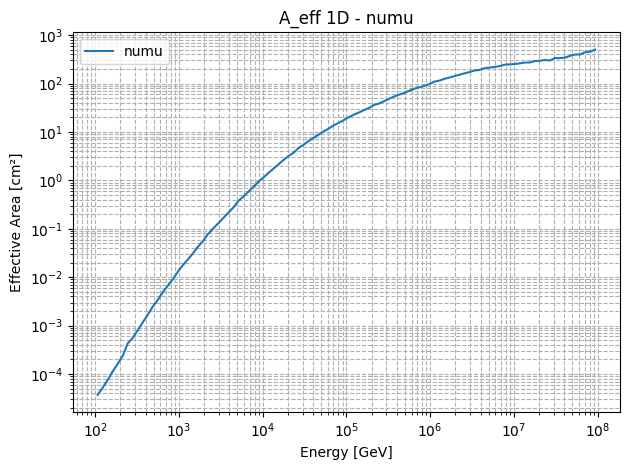

In [8]:
flavor_list = ["numu", "anumu", "nue", "anue"]
aeff_data = load_aeff_multi("aeff_summary_v9_flavors.hdf5", flavor_list)

# Access individual flavor data
flavor = "numu"
aeff_1d = aeff_data[flavor]["aeff_1d"]
energy_bins = aeff_data[flavor]["energy_bins"]

# Optional: plot it
import matplotlib.pyplot as plt
import numpy as np

energy_centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])
plt.loglog(energy_centers, aeff_1d, label=flavor)
plt.xlabel("Energy [GeV]")
plt.ylabel("Effective Area [cm²]")
plt.title(f"A_eff 1D - {flavor}")
plt.grid(True, which="both", ls="--")
plt.legend()
plt.tight_layout()
plt.show()


### Calculation of Reconstruction Response

In [6]:
import numpy as np
from h5py import File
from astropy.table import Table
import os

def create_energy_histogram(input_file, output_file, pdgid = 14, bins_true=None, bins_reco=None):
    # Load the event data
    with File(input_file, 'r') as h5_file:
        EventList = Table.read(h5_file)
        pdgmask = (EventList['pdg_id'] == pdgid)
        E_mc = EventList[pdgmask]['energy_mc']
        E_reco = EventList[pdgmask]['energy']
        
        

    # Clean the data
    valid_mask = (
        ~np.isnan(E_mc) & 
        ~np.isnan(E_reco) & 
        (E_mc > 0) & 
        (E_reco > 0)
    )
    E_mc_clean = E_mc[valid_mask]
    E_reco_clean = E_reco[valid_mask]

    # Use default binning if not provided
    if bins_true is None:
        bins_true = np.logspace(2, 8, 100)
    if bins_reco is None:
        bins_reco = np.logspace(2, 8, 100)

    # Create the 2D histogram
    hist2d, xedges, yedges = np.histogram2d(E_mc_clean, E_reco_clean, bins=[bins_true, bins_reco])

    output_hdf5_file = output_file + "pdgid" + str(pdgid) + ".hdf5"
    # Save histogram and bin edges to HDF5
    with File(output_hdf5_file, 'w') as f_out:
        f_out.create_dataset("hist2d", data=hist2d)
        f_out.create_dataset("bins_true", data=xedges)
        f_out.create_dataset("bins_reco", data=yedges)

    print(f"Saved histogram to: {output_hdf5_file}")

input_file  ="/home/wecapstor3/capn/capn107h/combined_eventlists/arca_KM3NeT_00000133_0001_combined_4983084events_mc.hdf5"
output_file = "arca_energy_response_histogram.hdf5"

create_energy_histogram(input_file, output_file, pdgid=-14)

Saved histogram to: arca_energy_response_histogram.hdf5pdgid-14.hdf5


### Simlation energies of detected events from a given flux

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def powerLawFlux(E, Phi0, gamma, E0=1e5):
    """
    Returns differential flux at energy E [GeV], normalized at E0 [GeV].
    Phi0 in units of GeV^-1 cm^-2 s^-1 sr^-1.
    """
    return Phi0 * (E / E0) ** (-gamma)

def plot_event_counts_vs_energy_and_phi0_with_contours(
    phi0_values,
    energy_bins,
    mean_A_eff,
    gamma=1.5,
    T=1e6,
    Omega=2*np.pi,
    contour_levels=None,
    log_counts=True,
    E0=1e5,
    plot=False
):
    """
    Plots a 2D heatmap: event counts per energy bin vs. phi0, with optional contour overlays.

    Parameters:
    - phi0_values: array of flux normalization values [cm⁻² s⁻¹ sr⁻¹ GeV⁻¹]
    - energy_bins: array of energy bin edges [GeV]
    - mean_A_eff: array of mean effective areas per energy bin [cm²]
    - gamma: power-law index
    - T: exposure time [s]
    - Omega: solid angle [sr]
    - contour_levels: list of contour levels (in raw counts, not log10)
    - log_counts: whether to plot log10(counts)
    - E0: normalization energy [GeV]
    - plot: bool, if True will generate the plot
    """
    E_centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])
    dE = np.diff(energy_bins)

    counts_matrix = []
    for phi0 in phi0_values:
        flux = powerLawFlux(E_centers, phi0, gamma) # phi0 * (E_centers / E0) ** (-gamma)
        counts = flux * mean_A_eff * T * dE * Omega
        counts_matrix.append(counts)

    counts_matrix = np.array(counts_matrix)  # shape: (len(phi0_values), len(energy_bins)-1)

    if not plot:
        return counts_matrix

    # For plotting
    logE = np.log10(E_centers)
    logPhi0 = np.log10(phi0_values)
    X, Y = np.meshgrid(logE, logPhi0)

    Z = counts_matrix
    if log_counts:
        Z = np.where(Z > 0, Z, 1e-10)
        Z_plot = np.log10(Z)
    else:
        Z_plot = Z

    # Plot heatmap
    plt.figure(figsize=(10, 6))
    cmap = 'viridis'
    im = plt.imshow(Z_plot, aspect='auto', origin='lower',
                    extent=[logE.min(), logE.max(), logPhi0.min(), logPhi0.max()],
                    cmap=cmap)

    plt.xlabel("log10(Energy [GeV])")
    plt.ylabel("log10(Phi₀ [cm⁻² s⁻¹ sr⁻¹ GeV⁻¹])")
    cbar_label = "log10(Event Counts)" if log_counts else "Event Counts"
    plt.colorbar(im, label=cbar_label)

    # Add contours if requested
    if contour_levels is not None:
        contour_vals = np.log10(contour_levels) if log_counts else contour_levels
        CS = plt.contour(X, Y, Z_plot, levels=contour_vals, colors='white', linewidths=1.5)
        plt.clabel(CS, fmt=lambda v: f"{10**v:.0f}" if log_counts else f"{v:.0f}", inline=True, fontsize=10)

    plt.title("Expected Event Counts per Energy Bin vs. Phi₀")
    plt.grid(True, which='both', ls='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


def simulate_detected_event_energies_from_flux(
    phi0,
    energy_bins,
    mean_A_eff,
    gamma=1.5,
    T=1e6,
    Omega=2*np.pi,
    n_events=None,
    E0=1e5,
    plot=False
):
    """
    Simulates detected event energies based on folded flux × effective area, with optional automatic estimation of n_events.
    
    Parameters:
    - phi0: flux normalization [cm⁻² s⁻¹ sr⁻¹ GeV⁻¹]
    - energy_bins: array of energy bin edges [GeV]
    - mean_A_eff: array of mean effective areas per energy bin [cm²]
    - gamma: spectral index
    - T: exposure time [s]
    - Omega: solid angle [sr]
    - n_events: number of events to simulate (if None, sample from Poisson of expected)
    - E0: normalization energy [GeV]
    - plot: bool, if True will plot the simulated energy distribution

    Returns:
    - simulated_energies: array of sampled event energies [GeV]
    - n_events: number of events simulated
    """
    E_centers = 0.5*(energy_bins[:-1] + energy_bins[1:])
    dE = np.diff(energy_bins)

    flux = powerLawFlux(E_centers, phi0, gamma) # phi0 * (E_centers / E0) ** (-gamma)
    weights = flux * mean_A_eff * T * dE * Omega

    MAX_EVENTS = int(1e8)
    if n_events is None:
        expected_total = np.sum(weights)
        n_events = np.random.poisson(expected_total)
        if n_events > MAX_EVENTS:
            print(f"Warning: n_events={n_events} is very large; truncating to {MAX_EVENTS}.")
            n_events = MAX_EVENTS


    if n_events == 0:
        if plot:
            print("No events to simulate (n_events=0).")
        return np.array([]), 0

    p_bins = weights / np.sum(weights)

    sampled_bins = np.random.choice(len(p_bins), size=n_events, p=p_bins)

    log_E_low = np.log10(energy_bins[sampled_bins])
    log_E_high = np.log10(energy_bins[sampled_bins + 1])
    simulated_logE = np.random.uniform(log_E_low, log_E_high)
    simulated_energies = 10**simulated_logE

    if plot:
        plt.figure(figsize=(8,5))
        plt.hist(simulated_energies, bins=energy_bins, histtype='step', color='blue', lw=1.5)
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel("Energy [GeV]")
        plt.ylabel("Number of events")
        plt.title(f"Simulated Detected Event Energies\nPhi0={phi0:.1e}, gamma={gamma}")
        plt.grid(True, which='both', ls='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

    return simulated_energies, n_events

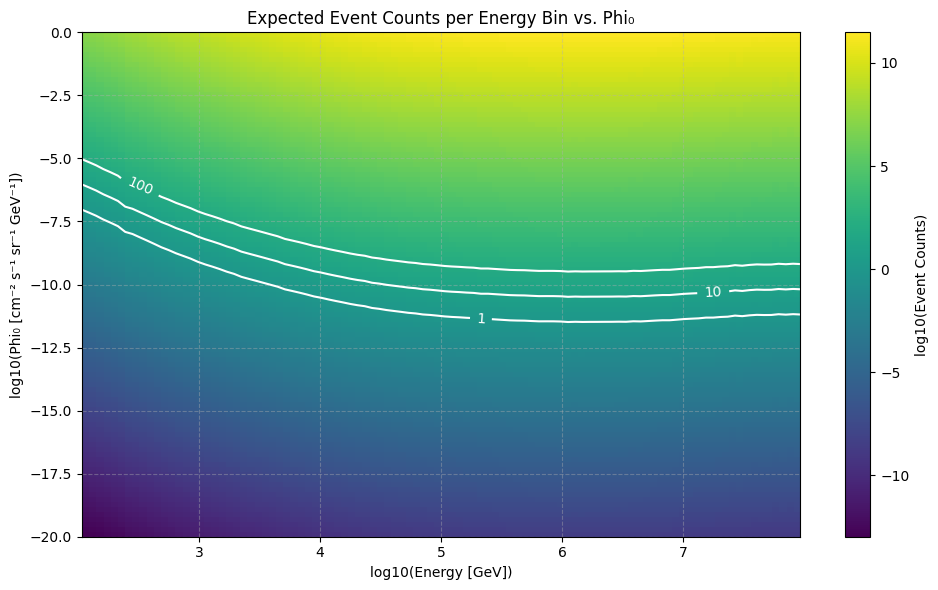

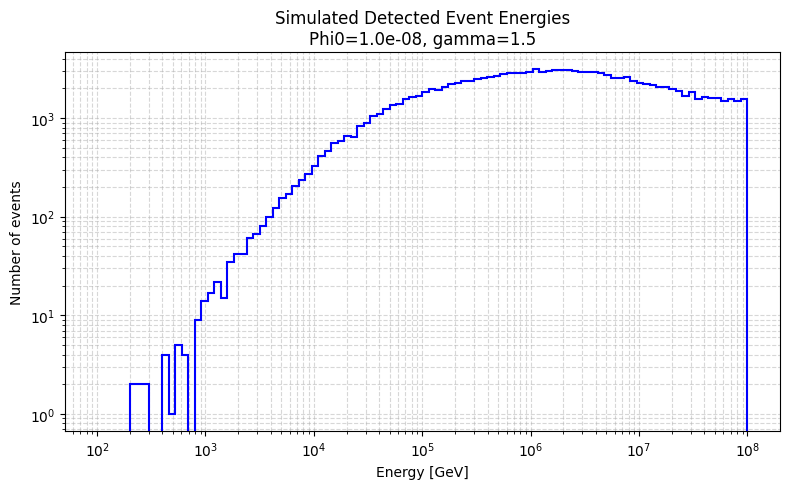

In [12]:
# Plot heatmap (only if plot=True)
phi0_values = np.logspace(-20, 0, 101)
gamma_values = np.linspace(1.0, 4.0, 51)
E_min, E_max = 1e2, 1e8  # GeV
energy_bins = np.logspace(np.log10(E_min), np.log10(E_max), 101)

time = 24*3600*90
angle =  2*np.pi *5/360 
contour_levels = [1, 10, 100] 

mean_A_eff = aeff_1d #aeff_1D['numu']


plot_event_counts_vs_energy_and_phi0_with_contours(
    phi0_values=phi0_values,
    energy_bins=energy_bins,
    mean_A_eff=mean_A_eff,
    gamma=1.5,
    T=time,
    Omega=angle,
    contour_levels=contour_levels,
    log_counts=True,
    plot=True
)

# Simulate and plot event energies (only if plot=True)
simulated_energies, n_events = simulate_detected_event_energies_from_flux(
    phi0=1e-8,
    energy_bins=energy_bins,
    mean_A_eff=mean_A_eff,
    gamma=1.5,
    T=time,
    Omega=angle,
    n_events=None,
    plot=True
)

### Sampling of reconstructed energies from expected detected

In [13]:
from h5py import File

def load_histogram(file_path):
    with File(file_path, 'r') as f:
        hist2d = f['hist2d'][()]
        bins_true = f['bins_true'][()]
        bins_reco = f['bins_reco'][()]
    return hist2d, bins_true, bins_reco

histogram_file = "arca_energy_response_histogram.hdf5pdgid14.hdf5"
#histogram_file = "arca_energy_response_histogram.hdf5"
hist2d, bins_true, bins_reco = load_histogram(histogram_file)

Successfully sampled: 136033 / 136033


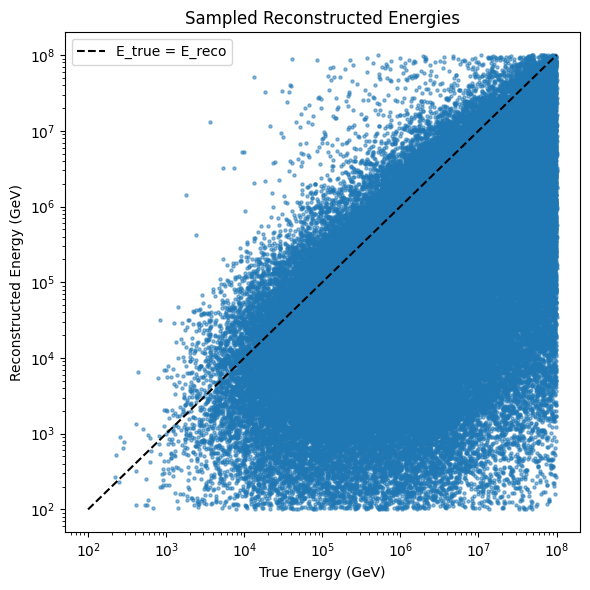

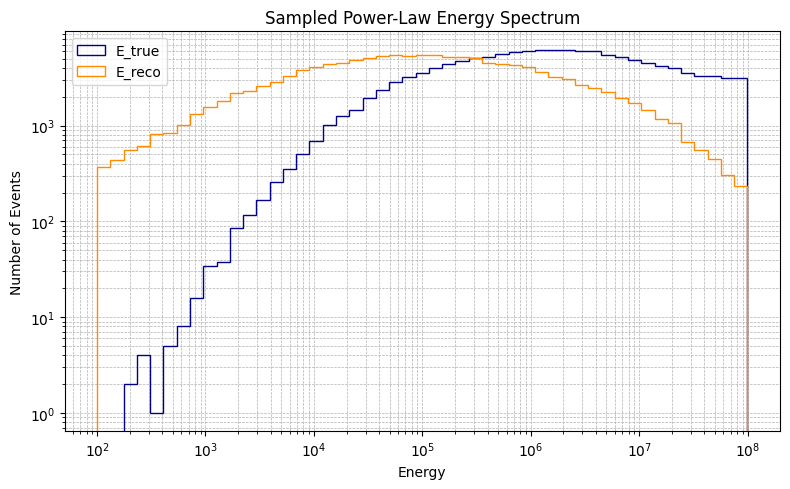

In [14]:
def sample_reco_energy_array(true_energies, hist2d, bins_true, bins_reco):
    """
    Samples reconstructed energies for an array of true energies based on a 2D histogram.

    Parameters:
    - true_energies: array-like, true neutrino energies
    - hist2d: 2D array of shape (n_true_bins, n_reco_bins), probability distribution
    - bins_true: edges of true energy bins
    - bins_reco: edges of reco energy bins

    Returns:
    - reco_samples: sampled reconstructed energies
    - failed_mask: boolean mask for entries that failed to sample (outside bin range or empty PDF)
    """
    true_energies = np.asarray(true_energies)
    reco_samples = np.full_like(true_energies, np.nan, dtype=float)

    for i, E_true in enumerate(true_energies):
        true_bin_idx = np.digitize(E_true, bins_true) - 1

        # Check if within valid range
        if 0 <= true_bin_idx < hist2d.shape[0]:
            slice_hist = hist2d[true_bin_idx, :]
            if np.sum(slice_hist) > 0:
                pdf = slice_hist / np.sum(slice_hist)
                reco_bin_idx = np.random.choice(len(pdf), p=pdf)

                # Sample uniformly in the selected reco bin
                reco_lo = bins_reco[reco_bin_idx]
                reco_hi = bins_reco[reco_bin_idx + 1]
                reco_samples[i] = np.random.uniform(reco_lo, reco_hi)

    failed_mask = np.isnan(reco_samples)
    return reco_samples, failed_mask

E_reco_samples, failed = sample_reco_energy_array(simulated_energies, hist2d, bins_true, bins_reco)

# Print how many succeeded
print(f"Successfully sampled: {(~failed).sum()} / {len(simulated_energies)}")


# Example plot: true vs reco energies
plt.figure(figsize=(6, 6))
plt.scatter(simulated_energies[~failed], E_reco_samples[~failed], s=5, alpha=0.5)
plt.plot([1e2, 1e8], [1e2, 1e8], 'k--', label='E_true = E_reco')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("True Energy (GeV)")
plt.ylabel("Reconstructed Energy (GeV)")
plt.title("Sampled Reconstructed Energies")
plt.legend()
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 5))
E_min = E_reco_samples.min()
E_max = E_reco_samples.max()
gamma = 2.0

bins = np.logspace(np.log10(E_min), np.log10(E_max), 50)
plt.hist(simulated_energies, bins=bins, histtype='step', color='darkblue', label=f'E_true')#, density=True)
plt.hist(E_reco_samples, bins=bins, histtype='step', color='darkorange', label=f'E_reco')#, density=True)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy')
plt.ylabel('Number of Events')
plt.title('Sampled Power-Law Energy Spectrum')
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [110]:
print(E_reco_samples)
print(len(E_reco_samples))

[ 713531.81745526   11454.87407441 9567012.15358305 ...   99422.18894513
   23523.51828169  219102.8863001 ]
136593


#### Outdated: Calculate event times

In [ ]:
from docopt import docopt
import h5py as h5py
import numpy as np
from plens.PulseModel import MVMD, sinusoid
from stingray import EventList, Lightcurve
import matplotlib.pyplot as plt
import km3io.definitions as kd


def inject_signal_times(time, energy, reco_energies_to_inject, bin_time, pulseshape, frequency,
                        baseline, a, phi, method='classic', kappa=None, num_periods=20, plot=False):
    """
    Injects signal times into an event list using a chosen method ('classic' or 'base').

    Parameters:
        time : np.array
            Original event times.
        energy : np.array
            Original event energies.
        reco_energies_to_inject : np.array
            Pre-sampled reconstructed energies to inject.
        bin_time : float
            Time bin width.
        pulseshape : str
            Pulse shape to use ('sine' or 'mvm').
        frequency : float
            Frequency of the pulse train.
        baseline : float
            Baseline offset.
        a : float
            Amplitude of the signal.
        phi : float
            Phase shift.
        method : str
            Injection method ('classic' or 'base').
        kappa : float, optional
            Shape parameter for MVM.
        num_periods : int
            Only used if method='base'. Number of periods for base interval.
        plot : bool
            Whether to return internal lightcurves for diagnostics.

    Returns:
        tuple: (combined_times, combined_energies) or diagnostic output if plot=True.
    """
    n_events_inject = len(reco_energies_to_inject)
    total_events = len(time)
    num_original_events_to_keep = total_events - n_events_inject

    if num_original_events_to_keep < 0:
        raise ValueError("Number of injected events exceeds original events.")

    if method == 'classic':
        high_res_bin_time = 1e-1
        high_res_time = np.arange(time.min(), time.max(), high_res_bin_time)

        if pulseshape == 'mvm':
            counts = MVMD(high_res_time, frequency, phi, kappa, a, baseline=baseline)
        elif pulseshape == 'sine':
            counts = sinusoid(high_res_time, frequency, baseline, a, phi)
        else:
            raise ValueError("Invalid pulseshape")

        lc_original = Lightcurve(high_res_time, counts, dt=high_res_bin_time / 10, skip_checks=True)
        ev = EventList()
        ev.simulate_times(lc_original)
        new_event_times = ev.time

    elif method == 'base':
        start_time = time.min()
        base_interval_length = num_periods / frequency
        high_res_time = np.arange(start_time, start_time + base_interval_length, bin_time)

        if pulseshape == 'mvm':
            counts = MVMD(high_res_time, frequency, phi, kappa, a, baseline=baseline)
        elif pulseshape == 'sine':
            counts = sinusoid(high_res_time, frequency, baseline, a, phi)
        else:
            raise ValueError("Invalid pulseshape")
        

        lc_base = Lightcurve(high_res_time, counts, dt=bin_time, skip_checks=True)
        ev = EventList()
        ev.simulate_times(lc_base)
        base_event_times = ev.time

        total_time_span = time.max() - time.min()
        num_intervals = int(np.ceil(total_time_span / base_interval_length))
        chosen_base_times = np.random.choice(base_event_times, n_events_inject, replace=True)
        random_shifts = np.random.randint(0, num_intervals, size=n_events_inject) * base_interval_length
        new_event_times = chosen_base_times + random_shifts

    else:
        raise ValueError("Invalid method: choose 'classic' or 'base'")

    # Resample if needed
    if len(new_event_times) >= n_events_inject:
        indices_to_keep_new = np.random.choice(len(new_event_times), n_events_inject, replace=False)
    else:
        indices_to_keep_new = np.random.choice(len(new_event_times), n_events_inject, replace=True)
    new_event_times = new_event_times[indices_to_keep_new]

    # Select original events to keep
    indices_to_keep_original = np.random.choice(len(time), num_original_events_to_keep, replace=False)
    remaining_original_times = time[indices_to_keep_original]
    remaining_original_energies = energy[indices_to_keep_original]

    reco_dirs = sample_reco_directions_from_source_skycoord(
        source_coord=skycoord,
        reco_energies=reco_energies_to_inject,
        resolution_func=lambda e: 0.5,  # 5 deg for now
        detector_location=detector_location,
        observation_time= new_event_times
    )

    # Combine and sort
    combined_times = np.concatenate((remaining_original_times, new_event_times))
    combined_energies = np.concatenate((remaining_original_energies, reco_energies_to_inject))
    sort_indices = np.argsort(combined_times)
    combined_times = combined_times[sort_indices]
    combined_energies = combined_energies[sort_indices]

    return combined_times, combined_energies


In [45]:
from h5py import File
from astropy.table import Table

input_file = "/home/hpc/capn/capn107h/software/nextflow_output/combined_eventlists/arca_KM3NeT_00000133_0001_combined_30929077events.hdf5"
input_file = "/home/hpc/capn/capn107h/software/nextflow_output/combined_eventlists/arca_KM3NeT_00000133_0001_combined_4982323events.hdf5"
#input_file = "/home/hpc/capn/capn107h/software/nextflow_output/combined_eventlists/arca_KM3NeT_00000133_0001_combined_7923events.hdf5"
with File(input_file, 'r') as h5_file:
        eventList = Table.read(h5_file)
    
        event_times = eventList['time'].value.astype(float)
        energy = eventList['energy'].value.astype(float)


combined_times, combined_energies = inject_signal_times(
    time=event_times,
    energy=energy,
    reco_energies_to_inject=E_reco_samples,
    bin_time=1e-5,
    pulseshape='mvm',
    frequency=11,
    baseline=0.0,
    a=1.0,
    phi=0.0,
    method='base',
    kappa=5.0
)


### New approach to calculate event times to the sampled energies with direction sampling from below providing new azimuth and zenith

In [21]:
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord, AltAz, EarthLocation
from astropy.time import Time

import h5py as h5py
import numpy as np
from plens.PulseModel import MVMD, sinusoid
from stingray import EventList, Lightcurve
import matplotlib.pyplot as plt
import km3io.definitions as kd

def sample_reco_directions_from_source_skycoord(
    source_coord,
    reco_energies,
    resolution_func,
    detector_location,
    observation_time
):
    """
    Simulate reconstructed directions (zenith, azimuth) around a source SkyCoord.

    Parameters:
    - source_coord: SkyCoord
        The true source celestial coordinate.
    - reco_energies: np.ndarray
        Reconstructed energies for the injected events.
    - resolution_func: callable
        Function that maps energy to angular resolution in degrees.
    - detector_location: EarthLocation
        Location of the detector.
    - observation_time: Time or float
        Observation time (astropy Time or UNIX timestamp).

    Returns:
    - dict with 'zenith', 'azimuth', 'zenith_true', 'azimuth_true', 'separation'
    """

    # Ensure time is Time object
    if isinstance(observation_time, (float, int)):
        observation_time = Time(observation_time, format='unix')

    n_events = len(reco_energies)
    ang_res_deg = resolution_func(reco_energies)  # e.g., 1-40 deg

    # Create duplicated SkyCoord array for source
    source_coords = SkyCoord(
        ra=np.full(n_events, source_coord.ra.degree) * u.deg,
        dec=np.full(n_events, source_coord.dec.degree) * u.deg,
        frame='icrs'
    )

    # Convert angular resolution (in deg) to radians and sample points
    angular_offsets = np.random.normal(loc=0, scale=ang_res_deg, size=n_events) * u.deg
    position_angles = np.random.uniform(0, 360, size=n_events) * u.deg

    # Offset the source in RA/Dec by these angles
    smeared_coords = source_coords.directional_offset_by(position_angles, angular_offsets)

    # Transform to AltAz (local detector frame)
    altaz_frame = AltAz(obstime=observation_time, location=detector_location)
    smeared_altaz = smeared_coords.transform_to(altaz_frame)
    true_altaz = source_coord.transform_to(altaz_frame)

    azimuths = smeared_altaz.az.to(u.deg).value
    zeniths = (90 * u.deg - smeared_altaz.alt).to(u.deg).value

    # Also return true direction
    az_true = true_altaz.az.to(u.deg).value
    zen_true = (90 * u.deg - true_altaz.alt).to(u.deg).value

    return {
        'zenith': zeniths,
        'azimuth': azimuths,
        'zenith_true': np.full(n_events, zen_true),
        'azimuth_true': np.full(n_events, az_true),
        'skycoord': smeared_coords,
        'separation': smeared_coords.separation(source_coord).to(u.deg).value
    }


In [22]:
import numpy as np

from astropy.coordinates import ICRS, Galactic, FK4, FK5  # Low-level frames
import astropy.units as u
from astropy.units import rad, deg, hourangle  # noqa

from astropy.coordinates import (
    EarthLocation,
    SkyCoord,
    AltAz,
    Longitude,
    Latitude,
)

from km3astro.constants import (
    arca_longitude,
    arca_latitude,
    arca_height,
    orca_longitude,
    orca_latitude,
    orca_height,
    antares_longitude,
    antares_latitude,
    antares_height,
)

LOCATIONS = {
    "arca": EarthLocation.from_geodetic(
        lon=Longitude(arca_longitude * deg),
        lat=Latitude(arca_latitude * deg),
        height=arca_height,
    ),
    "orca": EarthLocation.from_geodetic(
        lon=Longitude(orca_longitude * deg),
        lat=Latitude(orca_latitude * deg),
        height=orca_height,
    ),
    "antares": EarthLocation.from_geodetic(
        lon=Longitude(antares_longitude * deg),
        lat=Latitude(antares_latitude * deg),
        height=antares_height,
    ),
}


def get_location(location):
    try:
        loc = LOCATIONS[location]
    except KeyError:
        raise KeyError("Invalid location, valid are 'orca', 'arca', 'antares'")
    return loc


In [23]:
import numpy as np
from astropy.time import Time

def inject_signal_times(time, energy, zenith, azimuth, reco_energies_to_inject, bin_time, pulseshape, frequency,
                        baseline, a, phi, method='classic', kappa=None, num_periods=20, plot=False,
                        skycoord=None, detector_location=None, print_summary=True, preview_n=5):
    """
    Injects signal times into an event list and returns the combined times, energies, and directions.
    Optionally prints a summary of event counts and previews a few example events.

    Parameters:
        ...
        print_summary : bool
            Whether to print a summary of the injection process.
        preview_n : int
            Number of randomly selected events to print as a preview.
    """
    n_events_inject = len(reco_energies_to_inject)
    total_events = len(time)
    num_original_events_to_keep = total_events - n_events_inject

    if num_original_events_to_keep < 0:
        raise ValueError("Number of injected events exceeds original events.")

    # --- Injection process ---
    if method == 'classic':
        high_res_bin_time = 1e-1
        high_res_time = np.arange(time.min(), time.max(), high_res_bin_time)

        if pulseshape == 'mvm':
            counts = MVMD(high_res_time, frequency, phi, kappa, a, baseline=baseline)
        elif pulseshape == 'sine':
            counts = sinusoid(high_res_time, frequency, baseline, a, phi)
        else:
            raise ValueError("Invalid pulseshape")

        lc_original = Lightcurve(high_res_time, counts, dt=high_res_bin_time / 10, skip_checks=True)
        ev = EventList()
        ev.simulate_times(lc_original)
        new_event_times = ev.time

    elif method == 'base':
        start_time = time.min()
        base_interval_length = num_periods / frequency
        high_res_time = np.arange(start_time, start_time + base_interval_length, bin_time)

        if pulseshape == 'mvm':
            counts = MVMD(high_res_time, frequency, phi, kappa, a, baseline=baseline)
        elif pulseshape == 'sine':
            counts = sinusoid(high_res_time, frequency, baseline, a, phi)
        else:
            raise ValueError("Invalid pulseshape")

        lc_base = Lightcurve(high_res_time, counts, dt=bin_time, skip_checks=True)
        ev = EventList()
        ev.simulate_times(lc_base)
        base_event_times = ev.time

        total_time_span = time.max() - time.min()
        num_intervals = int(np.ceil(total_time_span / base_interval_length))
        chosen_base_times = np.random.choice(base_event_times, n_events_inject, replace=True)
        random_shifts = np.random.randint(0, num_intervals, size=n_events_inject) * base_interval_length
        new_event_times = chosen_base_times + random_shifts

    else:
        raise ValueError("Invalid method: choose 'classic' or 'base'")

    # --- Resample injected events if needed ---
    if len(new_event_times) >= n_events_inject:
        indices_to_keep_new = np.random.choice(len(new_event_times), n_events_inject, replace=False)
    else:
        indices_to_keep_new = np.random.choice(len(new_event_times), n_events_inject, replace=True)
    new_event_times = new_event_times[indices_to_keep_new]

    # --- Select original events to keep ---
    indices_to_keep_original = np.random.choice(len(time), num_original_events_to_keep, replace=False)
    remaining_original_times = time[indices_to_keep_original]
    remaining_original_energies = energy[indices_to_keep_original]
    remaining_original_zeniths = zenith[indices_to_keep_original]
    remaining_original_azimuths = azimuth[indices_to_keep_original]

    # --- Sample directions for injected events ---
    reco_dirs = sample_reco_directions_from_source_skycoord(
        source_coord=skycoord,
        reco_energies=reco_energies_to_inject,
        resolution_func=lambda e: 0.5,  # 5 deg resolution for now
        detector_location=detector_location,
        observation_time=Time(new_event_times, format='unix')
    )
    new_event_zeniths = reco_dirs['zenith']
    new_event_azimuths = reco_dirs['azimuth']

    # --- Combine and sort ---
    combined_times = np.concatenate((remaining_original_times, new_event_times))
    combined_energies = np.concatenate((remaining_original_energies, reco_energies_to_inject))
    combined_zeniths = np.concatenate((remaining_original_zeniths, new_event_zeniths))
    combined_azimuths = np.concatenate((remaining_original_azimuths, new_event_azimuths))

    sort_indices = np.argsort(combined_times)
    combined_times = combined_times[sort_indices]
    combined_energies = combined_energies[sort_indices]
    combined_zeniths = combined_zeniths[sort_indices]
    combined_azimuths = combined_azimuths[sort_indices]

    # --- Summary Output ---
    if print_summary:
        print("\n--- Signal Injection Summary ---")
        print(f"Total original events:      {total_events}")
        print(f"Simulated (injected) events: {n_events_inject} ({n_events_inject / total_events * 100:.2f}%)")
        print(f"Original events kept:        {num_original_events_to_keep} ({num_original_events_to_keep / total_events * 100:.2f}%)")
        print(f"Combined total events:       {len(combined_times)}")

        # Preview a few combined events
        print(f"\n--- Preview of {preview_n} Random Combined Events ---")
        preview_indices = np.random.choice(len(combined_times), min(preview_n, len(combined_times)), replace=False)
        for idx in preview_indices:
            print(f"[{idx}] Time: {combined_times[idx]:.2f}, Energy: {combined_energies[idx]:.2f}, "
                  f"Zenith: {combined_zeniths[idx]:.2f}, Azimuth: {combined_azimuths[idx]:.2f}")

    return combined_times, combined_energies, combined_zeniths, combined_azimuths


In [24]:
from astropy.coordinates import SkyCoord, EarthLocation
#from km3astro.coordinates import get_location
source_file = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/km3net_analysis/inputs/sources/Vela_X-1.h5"
# Load skycoord from file as you described
with File(source_file, 'r') as f:
    ra = f['skycoord/ra'][()]
    dec = f['skycoord/dec'][()]
    skycoord = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)

# Detector location
detector_location = get_location('arca')
from h5py import File
from astropy.table import Table

input_file = "/home/hpc/capn/capn107h/software/nextflow_output/combined_eventlists/arca_KM3NeT_00000133_0001_combined_30929077events.hdf5"
input_file = "/home/hpc/capn/capn107h/software/nextflow_output/combined_eventlists/arca_KM3NeT_00000133_0001_combined_4982323events.hdf5"
#input_file = "/home/hpc/capn/capn107h/software/nextflow_output/combined_eventlists/arca_KM3NeT_00000133_0001_combined_7923events.hdf5"
with File(input_file, 'r') as h5_file:
        eventList = Table.read(h5_file)
    
combine_times, combined_energies, combined_zeniths, combined_azimuths = inject_signal_times(
    time=eventList['time'].value.astype(float),
    energy=eventList['energy'].value.astype(float),
    zenith=eventList['zenith'],
    azimuth=eventList['azimuth'],
    reco_energies_to_inject=E_reco_samples,
    bin_time=1e-5,
    pulseshape='mvm',
    frequency=11,
    baseline=0.0,
    a=1.0,
    phi=0.0,
    method='base',
    kappa=5.0,
    skycoord=skycoord,
    detector_location=detector_location
)



--- Signal Injection Summary ---
Total original events:      4982323
Simulated (injected) events: 136033 (2.73%)
Original events kept:        4846290 (97.27%)
Combined total events:       4982323

--- Preview of 5 Random Combined Events ---
[1570702] Time: 1690386708.40, Energy: 98366.33, Zenith: 2.17, Azimuth: 2.55
[1115762] Time: 1689723736.34, Energy: 102.94, Zenith: 0.73, Azimuth: 1.83
[1544950] Time: 1690358144.99, Energy: 262570.21, Zenith: 1.44, Azimuth: 0.72
[3288349] Time: 1692493539.16, Energy: 21695489.55, Zenith: 2.20, Azimuth: 4.06
[149994] Time: 1688548646.55, Energy: 20811.38, Zenith: 1.44, Azimuth: 1.11


4982323


In [ ]:
def create_binned_light_curve(times, bin_size_seconds=60):
    """Plot a binned light curve for the given event times."""
    if len(times) == 0:
        print("No events to plot.")
        return
    
    start_time, end_time = np.min(times), np.max(times) 
    num_bins = int((end_time - start_time) / bin_size_seconds)
    
    event_counts, bin_edges = np.histogram(times, bins=num_bins, range=(start_time, end_time))
    bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
    
    return bin_centers, event_counts

def plot_data_comparison(original_times, injected_signal_times, frequency, num_cycles=5, bin_size_seconds = None):
    """
    Plots a comparison between the initial dataset and the injected light curve.
    
    Parameters:
        lc_initial : Lightcurve
            Light curve of the original data before injection.
        lc_injected : Lightcurve
            Light curve of the dataset after injection.
        frequency : float
            The frequency of the signal (used to calculate the period).
        num_cycles : int, optional
            Number of signal periods to display (default is 5).
    """
    plt.figure(figsize=(10, 5))

    
    
    # Calculate period from frequency
    period = 1 / frequency  # Period of the signal
    if bin_size_seconds == None: bin_size_seconds = period/20.0

    # Define the time range to plot
    t_min = np.min([original_times[0],injected_signal_times[0]]) + period
    t_max = t_min + (num_cycles + 2) * period

    

    original_times_bin_centers, original_event_counts = create_binned_light_curve(original_times,bin_size_seconds=bin_size_seconds)
    injected_signal_bin_centers, injected_signal_counts = create_binned_light_curve(injected_signal_times,bin_size_seconds=bin_size_seconds)

    

    # Plot both initial and injected light curves within the specified time range
    plt.plot(original_times_bin_centers, original_event_counts, drawstyle='steps-mid', lw=4, label="Original Data", color='darkorange', alpha=1)
    plt.plot(injected_signal_bin_centers, injected_signal_counts, drawstyle='steps-mid', lw=2, label="Injected Data", color='darkblue', alpha=1)
    
    plt.xlabel("Time (s)")
    plt.ylabel("Intensity")
    plt.title(f"Initial vs Injected Light Curve ({num_cycles} cycles - {frequency:.2e} Hz - Rate {rate} 1/d)")
    plt.xlim([t_min+0.5*period,t_max-1.5*period])
    plt.legend()
    plt.grid(alpha=0.5)

plot_data_comparison(event_times, combined_times, 11)

: 

In [26]:

from astropy.timeseries import TimeSeries

TimeEventList= TimeSeries(time=Time(combine_times, format='unix'))
InjectedEventList = eventList.copy()
InjectedEventList['time'] = TimeEventList['time']
InjectedEventList['energy'] = combined_energies #* EventList['energy'].unit
InjectedEventList['zenith'] = combined_zeniths
InjectedEventList['azimuth'] = combined_azimuths

#### outdated: Sampling of new source direction based on the estimated angular resolution

In [49]:
from astropy.coordinates import EarthLocation
from astropy.time import Time
from h5py import File

source_file = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/km3net_analysis/inputs/sources/Vela_X-1.h5"

#detector_location = EarthLocation(lat=36.27*u.deg, lon=16.1*u.deg, height=-2500*u.m)
detector_location = get_location('arca')
observation_time = Time(1650000000.0, format='unix')

with File(source_file, 'r') as f:
        source_name = f['source_name'][()].decode('utf-8')
        print("Source Name:", source_name)

        # SkyCoord information
        ra = f['skycoord/ra'][()]
        dec = f['skycoord/dec'][()]
        skycoord = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)
        print("SkyCoord:", skycoord)

    

reco_dirs = sample_reco_directions_from_source_skycoord(
    source_coord=skycoord,
    reco_energies=combined_energies,
    resolution_func=lambda e: 0.5,  # 5 deg for now
    detector_location=detector_location,
    observation_time=observation_time
)

Source Name: Vela_X-1
SkyCoord: <SkyCoord (ICRS): (ra, dec) in deg
    (135.5286, -40.5547)>


/tmp/ipykernel_2257077/1945550024.py:20: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


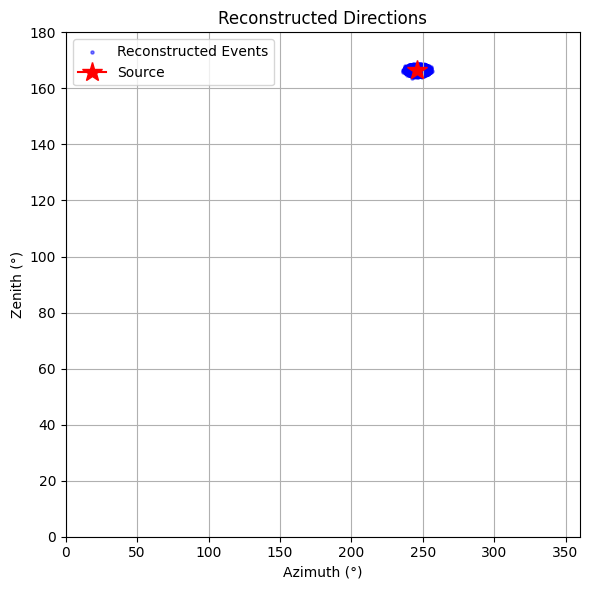

In [ ]:
import matplotlib.pyplot as plt

def plot_reco_directions(result, title="Reconstructed Directions"):
    zen = result['zenith']
    az = result['azimuth']
    zen_true = result['zenith_true'][0]
    az_true = result['azimuth_true'][0]

    fig, ax = plt.subplots(figsize=(6, 6))
    sc = ax.scatter(az, zen, s=5, alpha=0.5, label='Reconstructed Events', color='blue')
    ax.plot(az_true, zen_true, marker='*', color='red', markersize=15, label='Source')

    ax.set_xlim(0, 360)
    ax.set_ylim(0, 180)
    ax.set_xlabel("Azimuth (°)")
    ax.set_ylabel("Zenith (°)")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
    plt.tight_layout()

    plt.show()

plot_reco_directions(reco_dirs)

### Apply Selection Cuts 

In [27]:
import km3io.definitions as kd

def apply_selection_cuts(event_list, detector, energy_min, energy_max, nhits_tr_min,
                         nhits_sh_min, lik_tr_min, lik_sh_min, beta0_tr_max,
                         zenith_min, trackscore_low_max, trackscore_high_min):
    """Apply a set of selection cuts to a KM3NeT event list."""

    # Energy cut
    energy_mask = (event_list['energy'].value >= energy_min) & (event_list['energy'].value <= energy_max)
    event_list = event_list[energy_mask]

    # Track/Shower event selection
    track_events = (event_list['rec_type'] == kd.reconstruction.JPP_RECONSTRUCTION_TYPE) & \
                   (event_list['rec_stage'] == kd.reconstruction.JMUONBEGIN)

    if detector == 'arca':
        shower_events = (event_list['rec_type'] == kd.reconstruction.AANET_RECONSTRUCTION_TYPE) & \
                        (event_list['rec_stage'] == kd.reconstruction.AASHOWERBEGIN)
        hits_mask_shower = shower_events & (event_list['AASHOWERFIT_NUMBER_OF_HITS'] >= nhits_sh_min)
    elif detector == 'orca':
        shower_events = (event_list['rec_type'] == kd.reconstruction.JPP_RECONSTRUCTION_TYPE) & \
                        (event_list['rec_stage'] == kd.reconstruction.JSHOWERBEGIN)
        hits_mask_shower = shower_events & (event_list['JGANDALF_NUMBER_OF_HITS'] >= nhits_sh_min)
    else:
        raise ValueError(f"Unsupported detector: {detector}")

    # Hits cut
    hits_mask_track = track_events & (event_list['JGANDALF_NUMBER_OF_HITS'] >= nhits_tr_min)
    event_list = event_list[hits_mask_shower | hits_mask_track]

    # Re-derive events post hits cut
    track_events = (event_list['rec_type'] == kd.reconstruction.JPP_RECONSTRUCTION_TYPE) & \
                   (event_list['rec_stage'] == kd.reconstruction.JMUONBEGIN)
    shower_events = (event_list['rec_type'] == kd.reconstruction.AANET_RECONSTRUCTION_TYPE) & \
                    (event_list['rec_stage'] == kd.reconstruction.AASHOWERBEGIN) if detector == 'arca' else \
                    (event_list['rec_type'] == kd.reconstruction.JPP_RECONSTRUCTION_TYPE) & \
                    (event_list['rec_stage'] == kd.reconstruction.JSHOWERBEGIN)

    # Likelihood cut
    lik_mask_track = track_events & (np.abs(event_list['likelihood']) >= lik_tr_min)
    lik_mask_shower = shower_events & (np.abs(event_list['likelihood']) >= lik_sh_min)
    event_list = event_list[lik_mask_track | lik_mask_shower]

    # Zenith cut
    zenith_min_rad = zenith_min * np.pi / 180
    event_list = event_list[event_list['zenith'] >= zenith_min_rad]

    # Beta0 cut (only applies to tracks)
    track_events = (event_list['rec_type'] == kd.reconstruction.JPP_RECONSTRUCTION_TYPE) & \
                   (event_list['rec_stage'] == kd.reconstruction.JMUONBEGIN)
    shower_events = (event_list['rec_type'] == kd.reconstruction.AANET_RECONSTRUCTION_TYPE) & \
                    (event_list['rec_stage'] == kd.reconstruction.AASHOWERBEGIN) if detector == 'arca' else \
                    (event_list['rec_type'] == kd.reconstruction.JPP_RECONSTRUCTION_TYPE) & \
                    (event_list['rec_stage'] == kd.reconstruction.JSHOWERBEGIN)
    beta0_tr_mask = track_events & (event_list['JGANDALF_BETA0_RAD'] <= beta0_tr_max)
    event_list = event_list[beta0_tr_mask | shower_events]

    # Trackscore cut
    trackscore_mask = (event_list['track_score'] <= trackscore_low_max) | \
                      (event_list['track_score'] >= trackscore_high_min)
    event_list = event_list[trackscore_mask]

    return event_list


In [ ]:
cut_params = {
                'detector': str(arguments['--detector']),
                'energy_min': float(arguments['--energy_min']),
                'energy_max': float(arguments['--energy_max']),
                'nhits_tr_min': float(arguments['--nhits_tr_min']),
                'nhits_sh_min': float(arguments['--nhits_sh_min']),
                'lik_tr_min': float(arguments['--lik_tr_min']),
                'lik_sh_min': float(arguments['--lik_sh_min']),
                'beta0_tr_max': float(arguments['--beta0_tr_max']),
                'zenith_min': float(arguments['--zenith_min']),
                'trackscore_low_max': float(arguments['--trackscore_low_max']),
                'trackscore_high_min': float(arguments['--trackscore_high_min']),
            }

In [28]:
cut_params = {
                'detector': 'arca',
                'energy_min': 1e2,
                'energy_max': 1e8,
                'nhits_tr_min': 20,
                'nhits_sh_min': 20,
                'lik_tr_min': 50.,
                'lik_sh_min': 50.,
                'beta0_tr_max': 1,
                'zenith_min': 0,
                'trackscore_low_max': 0.5,
                'trackscore_high_min': 0.5,
            }

InjectedEventListWithCuts = apply_selection_cuts(InjectedEventList, **cut_params)
print(f"All cuts applied.")

All cuts applied.


In [29]:
len(InjectedEventListWithCuts['time'])

2340741

### Select Subsets

In [30]:
def extract_subset_within_gtis(event_list, gti_array, desired_length_days):
    """Extract a time-limited subset from event_list, using GTIs to accumulate real live-time."""
    subset_event_indices = []
    accumulated_live_time = 0.0
    used_gtis = []

    event_times = event_list['time']

    if gti_array is not None:
        for start, stop in gti_array:
            gti_duration = stop - start

            if accumulated_live_time + gti_duration > desired_length_days:
                remaining_time = desired_length_days - accumulated_live_time
                new_stop = start + remaining_time
                in_partial_gti = (event_times.value >= start) & (event_times.value < new_stop)
                selected = np.where(in_partial_gti)[0]
                subset_event_indices.extend(selected.tolist())
                used_gtis.append([start, new_stop])
                accumulated_live_time += remaining_time
                break
            else:
                in_gti = (event_times.value >= start) & (event_times.value <= stop)
                selected = np.where(in_gti)[0]
                subset_event_indices.extend(selected.tolist())
                used_gtis.append([start, stop])
                accumulated_live_time += gti_duration

            if accumulated_live_time >= desired_length_days:
                break
    else:
        first_time = event_times[0]
        last_time = first_time + desired_length_days
        in_range = (event_times >= first_time) & (event_times < last_time)
        subset_event_indices = np.where(in_range)[0].tolist()
        used_gtis = [[first_time.value, last_time.value]]
        accumulated_live_time = desired_length_days

    subset = event_list[subset_event_indices]
    return subset, accumulated_live_time, np.array(used_gtis)

event_times = InjectedEventListWithCuts['time']
current_gti = None

print("event_times[:10]: ", event_times[:10])
#print("current_gti[:3]: ", current_gti[:3])


# Apply GTI filtering mask as safety check
if current_gti is not None:
    mask = np.zeros_like(event_times, dtype=bool)
    for start, stop in current_gti:
        in_gti = (event_times.value >= start) & (event_times.value <= stop)
        mask |= in_gti
    filtered_events = InjectedEventListWithCuts[mask]
    filtered_times = event_times[mask]
else:
    filtered_events = InjectedEventListWithCuts
    filtered_times = event_times

print("filtered_times[:10]: ", filtered_times[:10])


# Compute total active time
if current_gti is not None:
    total_active_time = np.sum(current_gti[:, 1] - current_gti[:, 0])
else:
    total_active_time = filtered_times[-1] - filtered_times[0] # This messes up, not calculating time in seconds

total_active_time = event_times[-1].value - event_times[0].value
length = 60
desired_length = length#* 24.0*3600.0

total_active_time_days = total_active_time / (3600.0*24.0)
print(f"Total Active Time: {total_active_time} s - {total_active_time_days} days")
print(f"Chosen Length: {desired_length} s - {desired_length/(24.0*3600.0)} d")
print(f"Number of Events: {len(event_times)}")

event_times[:10]:  [1.68839640e+09 1.68839640e+09 1.68839640e+09 1.68839640e+09
 1.68839640e+09 1.68839641e+09 1.68839641e+09 1.68839641e+09
 1.68839641e+09 1.68839641e+09]
filtered_times[:10]:  [1.68839640e+09 1.68839640e+09 1.68839640e+09 1.68839640e+09
 1.68839640e+09 1.68839641e+09 1.68839641e+09 1.68839641e+09
 1.68839641e+09 1.68839641e+09]
Total Active Time: 6037195.765509367 s - 69.87495098969175 days
Chosen Length: 60 s - 0.0006944444444444445 d
Number of Events: 2340741


In [31]:
# Extract the GTI-respecting subset
InjectedEventListWithCutsSubset, used_live_time, used_gtis = extract_subset_within_gtis(InjectedEventListWithCuts, current_gti, desired_length)

used_live_time_seconds = used_live_time *(24.0*3600.0)
print(f"New Amount of Events for {used_live_time:.2f} days ({used_live_time_seconds:.2f} s): {len(InjectedEventListWithCutsSubset['time'])}")

InjectedEventListWithCutsSubset.meta['length'] = length

New Amount of Events for 60.00 days (5184000.00 s): 2002029


### Applying Epoch Folding

Times: [1.6883964e+09 1.6883964e+09 1.6883964e+09 ... 1.6935804e+09 1.6935804e+09
 1.6935804e+09]
First 10 Times: ['1688396401.076', '1688396401.345', '1688396401.416', '1688396401.486', '1688396403.165', '1688396405.297', '1688396405.928', '1688396406.507', '1688396406.927', '1688396407.705']
Last 10 Times: ['1693580383.919', '1693580383.933', '1693580385.230', '1693580388.294', '1693580392.453', '1693580392.993', '1693580394.400', '1693580396.023', '1693580397.404', '1693580397.908']
Number of available events: 2002029
Test frequencies: [10.75   10.7505 10.751  10.7515 10.752  10.7525 10.753  10.7535 10.754
 10.7545 10.755  10.7555 10.756  10.7565 10.757  10.7575 10.758  10.7585
 10.759  10.7595 10.76   10.7605 10.761  10.7615 10.762  10.7625 10.763
 10.7635 10.764  10.7645 10.765  10.7655 10.766  10.7665 10.767  10.7675
 10.768  10.7685 10.769  10.7695 10.77   10.7705 10.771  10.7715 10.772
 10.7725 10.773  10.7735 10.774  10.7745 10.775  10.7755 10.776  10.7765
 10.777  10.7775 10.

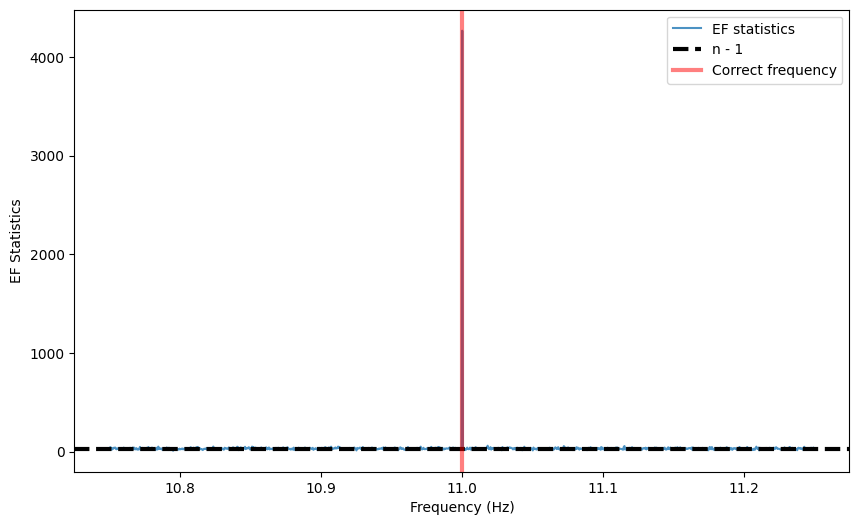

In [32]:
from stingray.pulse.search import epoch_folding_search, z_n_search, search_best_peaks
from epochfolding.stingray_epochfolding import savehdf5, get_testfrequencies
import stingray
import inspect
nbin = 32

FinalEventList= TimeSeries(time=Time(InjectedEventListWithCutsSubset['time'], format='unix'))

print(f"Times: {np.array(FinalEventList['time'].value)}")
frequencies = get_testfrequencies(11,1000, 5e-4)

print(f"First 10 Times: {[f'{x:.3f}' for x in np.array(FinalEventList['time'].value)[:10]]}")
print(f"Last 10 Times: {[f'{x:.3f}' for x in np.array(FinalEventList['time'].value)[-10:]]}")
print(f"Number of available events: {len(np.array(FinalEventList['time'].value))}")
print(f"Test frequencies: {frequencies}")
print(f"nbins: {nbin}")

freq, efstat = epoch_folding_search(
    np.array(FinalEventList['time'].value),
    frequencies,
    nbin=nbin,
    segment_size=1e10,
    gti=used_gtis
) 

#output_file_ef = output_file + f"_r{data['rate']}_I{data['iteration'].zfill(4)}_{data['frequency']}Hz_ef.hdf5"
#output_plot_ef = output_file + f"_r{data['rate']}_I{data['iteration'].zfill(4)}_{data['frequency']}Hz_efplot.png"

#if plot is True:
plt.figure()
plt.plot(freq, efstat, label='EF statistics', alpha=0.8)
plt.axhline(nbin- 1, ls='--', lw=3, color='k', label='n - 1')
plt.axvline(11, lw=3, alpha=0.5, color='r', label='Correct frequency')
plt.xlabel('Frequency (Hz)')
plt.ylabel('EF Statistics')
_ = plt.legend()

threshold = (np.max(efstat)*0.1+nbin - 1)
best_x, best_y = search_best_peaks(freq,efstat,threshold)
y_min, y_max = plt.ylim()
offset = 0.04 * (y_max - y_min)

'''
for i, (x_value, y_value) in enumerate(zip(best_x, best_y)):
    label = 'peaks' if i == 0 else None  # Label only the first line
    plt.axvline(x_value, ls='dotted', lw=2, color='k', label=label)

    # Annotate the peak with its y-value slightly to the righ
    #plt.text(x_value + 0.03e-5, y_value, f"{y_value:.2f}", color='darkorange', fontsize=10)
    plt.text(x_value + 0.03e-5, y_value, f"{x_value:.4e}", color='darkorange', fontsize=10)
    plt.text(x_value + 0.03e-5, y_value-offset, f"{(float(data['frequency'])/x_value):.2f}", color='darkorange', fontsize=10)
'''
#plt.savefig(output_plot_ef)

#print(f"Plot saved: {output_plot_ef}")

print(f"Stingray version: {stingray.__version__}")
print(f"epoch_folding_search is defined in: {inspect.getfile(epoch_folding_search)}")

#with h5py.File(output_file_ef, 'w') as out:
#    savehdf5(freq, efstat, out)